<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/%F0%9F%A7%AC_Multi_Resistance_Antibiotic_Susceptibility_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d adilimadeddinehosni/multi-resistance-antibiotic-susceptibility

# Unziping the downloaded file
!unzip multi-resistance-antibiotic-susceptibility.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/adilimadeddinehosni/multi-resistance-antibiotic-susceptibility
License(s): CC-BY-NC-SA-4.0
  0% 0.00/565k [00:00<?, ?B/s]
100% 565k/565k [00:00<00:00, 281MB/s]
Archive:  multi-resistance-antibiotic-susceptibility.zip
  inflating: Bacteria_dataset_Multiresictance.csv  


In [5]:
df = pd.read_csv('Bacteria_dataset_Multiresictance.csv')
df.head(11)

,ID,Name,Email,Address,age/gender,Souches,Diabetes,Hypertension,Hospital_before,Infection_Freq,...,AN,Acide nalidixique,ofx,CIP,C,Co-trimoxazole,Furanes,colistine,Collection_Date,Notes
0,S290,Elizabeth Lawrence,elizabeth.lawrence@example.com,"6350 Robinson Loaf Apt. 447, Paulfurt, RI 30252",37/F,S290 Escherichia coli,No,No,No,0.0,...,S,S,S,S,R,S,S,S,5 Fev 2025,Patient had fever??
1,S291,Tina Sanders,tina.sanders@example.com,"78594 Galloway Port Suite 762, South Tanyatown...",29/F,S291 Morganella morganii,True,No,No,3.0,...,S,S,S,S,S,S,S,S,08/05/2021,تم العلاج
2,S292,Erin Cooke,erin.cooke@example.com,"76661 Isaiah Manors, North Benjamin, HI 85195",77/F,S292 Proteus mirabilis,True,No,No,3.0,...,S,S,S,R,R,S,S,S,01/05/2022,NADA
3,S293,Mrs. Sharon Watson,mrs..sharon.watson@example.com,"1670 Thompson Way Apt. 520, Andrewbury, IL 11534",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-01-05,PACIENTO ENFERMO
4,S294,Erika Stewart,erika.stewart@example.com,"76838 Patrick Green Suite 538, Torresmouth, ME...",13/F,S294 Escherichia coli,No,Yes,No,1.0,...,R,S,S,S,S,S,S,S,error,NADA
5,S295,Krystal Riley,krystal.riley@example.com,"USNS Neal, FPO AA 98816",57/M,S295 Escherichia coli,True,No,No,3.0,...,R,S,S,S,S,S,S,S,2020-01-05,Patient had fever??
6,S296,Gina Griffin,gina.griffin@example.com,"389 Ferguson Island, West Jefferymouth, MT 89882",68/F,S296 Escherichia coli,No,No,No,3.0,...,S,S,S,S,S,S,S,S,2020-12-31,see file
7,S297,Faith Newman,faith.newman@example.com,"256 Bartlett Fork Suite 334, East Sherri, MI 9...",18/F,S297 Citrobacter spp.,No,No,No,2.0,...,S,S,S,S,S,R,S,S,05/03/2022,تم العلاج
8,S298,Russell Hicks,russell.hicks@example.com,"77940 Richard Brook Apt. 748, South Jessica, G...",77/F,S298 Enterobacteria spp.,No,No,No,0.0,...,S,S,S,S,S,S,S,S,05/01/2025,MALADIE GRAVE
9,S299,Kimberly Rodriguez,kimberly.rodriguez@example.com,"1979 Kayla Squares Suite 125, West Cynthia, MO...",36/F,S299 Proeus mirabilis,No,No,No,3.0,...,S,R,S,S,S,S,S,S,08/05/2021,Patient had fever??


In [6]:
df.tail(11)

,ID,Name,Email,Address,age/gender,Souches,Diabetes,Hypertension,Hospital_before,Infection_Freq,...,AN,Acide nalidixique,ofx,CIP,C,Co-trimoxazole,Furanes,colistine,Collection_Date,Notes
10699,S10989,Jennifer Sullivan,jennifer.sullivan@example.com,"8314 Christian Plaza, Anthonychester, MN 03824",84/F,S4001 Proteus mirabilis,No,Yes,Yes,missing,...,S,R,S,R,S,S,S,S,01/05/2022,NADA
10700,S10990,Erin Spencer,erin.spencer@example.com,"691 Michael Falls, Nathanville, FM 36475",57/F,S425 Escherichia coli,No,No,No,1.0,...,S,S,S,S,S,S,S,S,missing,--
10701,S10991,Ashley Simmons,ashley.simmons@example.com,"5375 Johnson Mills, West Laurie, GA 42736",72/F,S4849 Acinetobacter baumannii,No,No,Yes,2.0,...,S,S,R,S,S,S,R,S,5 Fev 2025,PACIENTO ENFERMO
10702,S10992,Kimberly Campos,kimberly.campos@example.com,"19622 Baxter Meadow Suite 804, Doyleview, UT 5...",40/F,S5073 Escherichia coli,True,No,No,2.0,...,S,S,S,R,R,S,S,S,2020-01-05,PACIENTO ENFERMO
10703,S10993,Andrew Hernandez,andrew.hernandez@example.com,"00818 Charles Trafficway, Chloeberg, FM 17501",48/M,S6240 Escherichia coli,True,Yes,No,3.0,...,R,S,S,S,S,S,R,S,2024-12-31,تم العلاج
10704,S10994,Melanie Scott,melanie.scott@example.com,"3979 Thomas Rapids, Lake Ianstad, RI 93324",43/F,S8862 Escherichia coli,No,No,No,0.0,...,S,R,S,S,R,S,S,S,?,تم العلاج
10705,S10995,Mrs. Chelsea Brown MD,mrs..chelsea.brown.md@example.com,"23574 Palmer Lodge, South Aliciaton, GU 00728",17/M,S7382 Enterobacteria spp.,No,No,No,3.0,...,S,S,S,S,S,S,S,S,2024-12-31,see file
10706,S10996,Mary Kelley,mary.kelley@example.com,"8194 Gonzalez Hill, Loveview, SD 31189",20/F,S1479 Proeus mirabilis,True,No,Yes,3.0,...,S,S,S,S,S,S,S,S,5 Fev 2025,Patient had fever??
10707,S10997,Alexandra Smith,alexandra.smith@example.com,"213 Yates Station, Port Meganstad, PW 17799",33/M,S2983 Escherichia coli,No,No,No,0.0,...,S,S,R,S,R,S,S,S,08/05/2021,Patient had fever??
10708,S10998,April Cox,april.cox@example.com,"985 Julia Freeway Apt. 753, Dianamouth, SD 07610",86/F,S10079 Escherichia coli,No,No,No,2.0,...,s,i,r,r,s,Intermediate,r,s,05/03/2022,see file


In [7]:
df.shape

(10710, 27)

In [8]:
df.columns

Index(['ID', 'Name', 'Email', 'Address', 'age/gender', 'Souches', 'Diabetes',
       'Hypertension', 'Hospital_before', 'Infection_Freq', 'AMX/AMP', 'AMC',
       'CZ', 'FOX', 'CTX/CRO', 'IPM', 'GEN', 'AN', 'Acide nalidixique', 'ofx',
       'CIP', 'C', 'Co-trimoxazole', 'Furanes', 'colistine', 'Collection_Date',
       'Notes'],
      dtype='object')

In [9]:
df.dtypes

,0
ID,object
Name,object
Email,object
Address,object
age/gender,object
Souches,object
Diabetes,object
Hypertension,object
Hospital_before,object
Infection_Freq,object


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10710 entries, 0 to 10709
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   ID                 10710 non-null  object
 1   Name               10710 non-null  object
 2   Email              10710 non-null  object
 3   Address            10710 non-null  object
 4   age/gender         10089 non-null  object
 5   Souches            10070 non-null  object
 6   Diabetes           10075 non-null  object
 7   Hypertension       10080 non-null  object
 8   Hospital_before    10073 non-null  object
 9   Infection_Freq     10071 non-null  object
 10  AMX/AMP            10052 non-null  object
 11  AMC                10078 non-null  object
 12  CZ                 10082 non-null  object
 13  FOX                10085 non-null  object
 14  CTX/CRO            10086 non-null  object
 15  IPM                10077 non-null  object
 16  GEN                10067 non-null  objec

In [12]:
df.describe(include = 'all').T

,count,unique,top,freq
ID,10710,10710,S10999,1
Name,10710,10005,William Smith,6
Email,10710,10005,william.smith@example.com,6
Address,10710,10710,"2903 James Motorway Suite 202, Whitakerside, C...",1
age/gender,10089,184,40/F,167
Souches,10070,9298,?,63
Diabetes,10075,4,No,7883
Hypertension,10080,4,No,7470
Hospital_before,10073,4,No,7008
Infection_Freq,10071,8,2.0,2966


In [13]:
df.isnull().sum()

,0
ID,0
Name,0
Email,0
Address,0
age/gender,621
Souches,640
Diabetes,635
Hypertension,630
Hospital_before,637
Infection_Freq,639


In [14]:
# Identifying numerical and categorical columns
numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include='object').columns

# For numerical columns, we might impute with the mean or median
for col in numerical_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].mean(), inplace=True)

# For categorical columns, we might impute with the mode or a constant
for col in categorical_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing values after handling:")
df.isnull().sum()


Missing values after handling:


,0
ID,0
Name,0
Email,0
Address,0
age/gender,0
Souches,0
Diabetes,0
Hypertension,0
Hospital_before,0
Infection_Freq,0


In [11]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

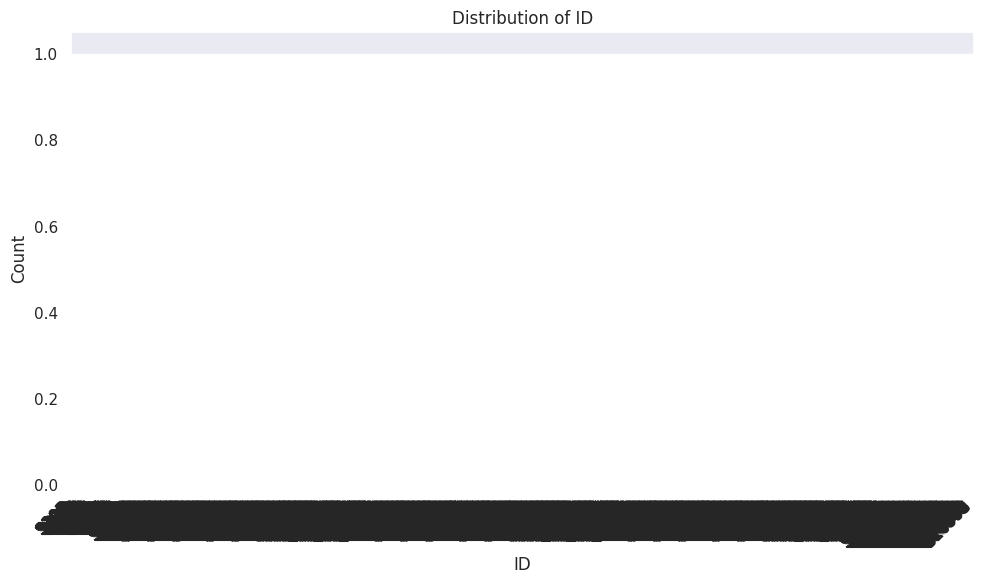

In [ ]:
# Getting a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterating through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

In [ ]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

In [ ]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank you